# 池化层

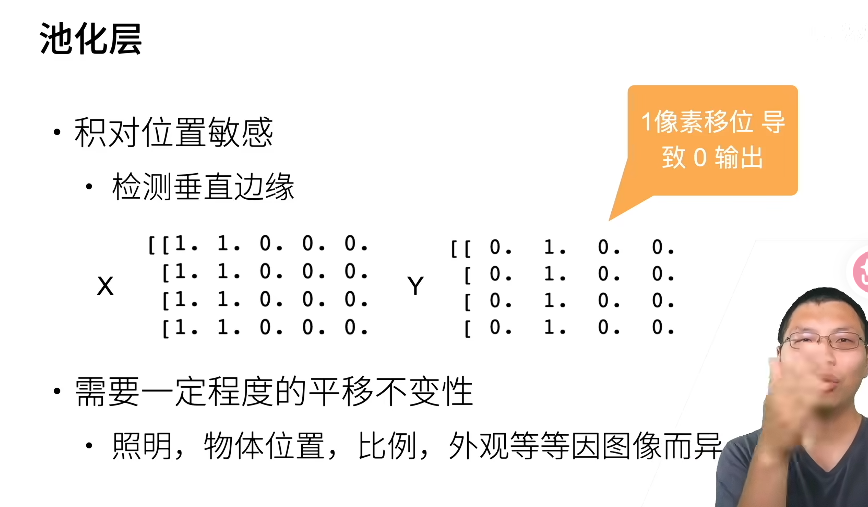

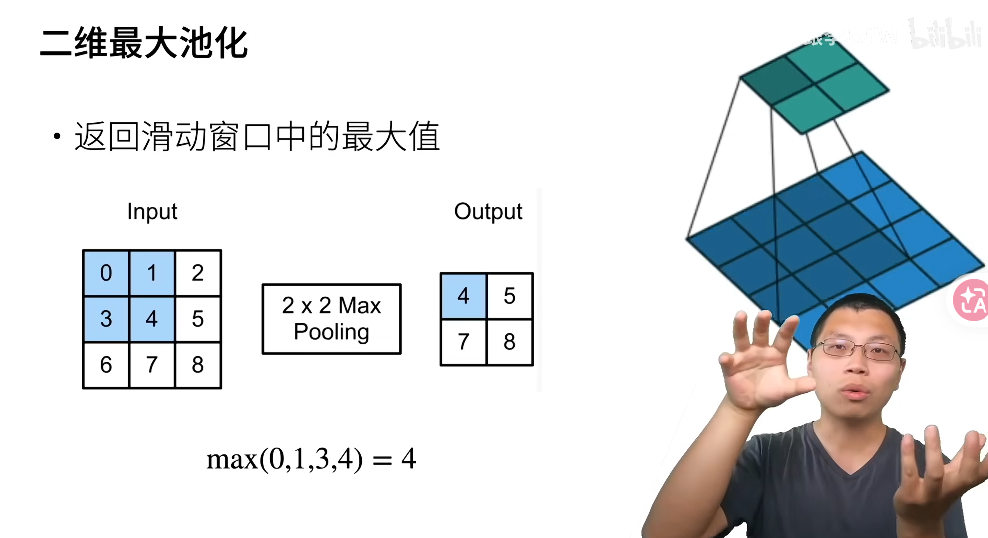

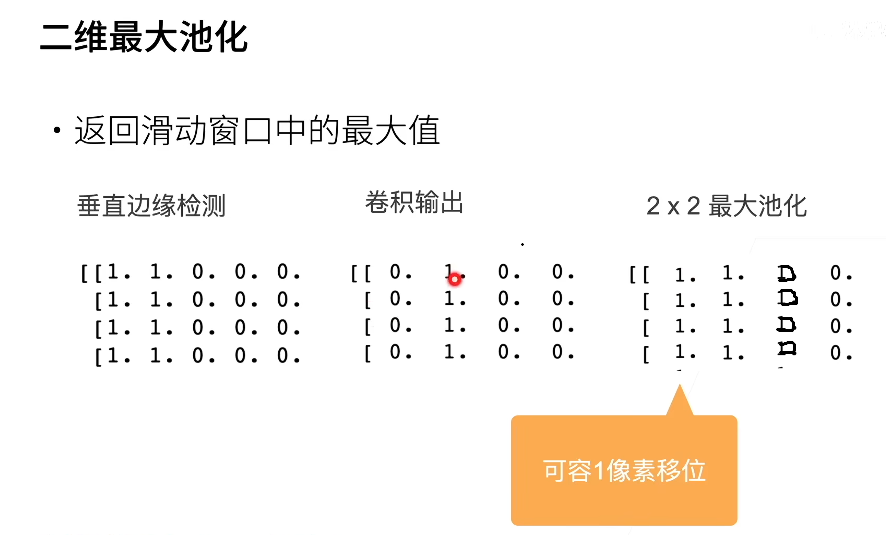

池化作用在卷积输出上

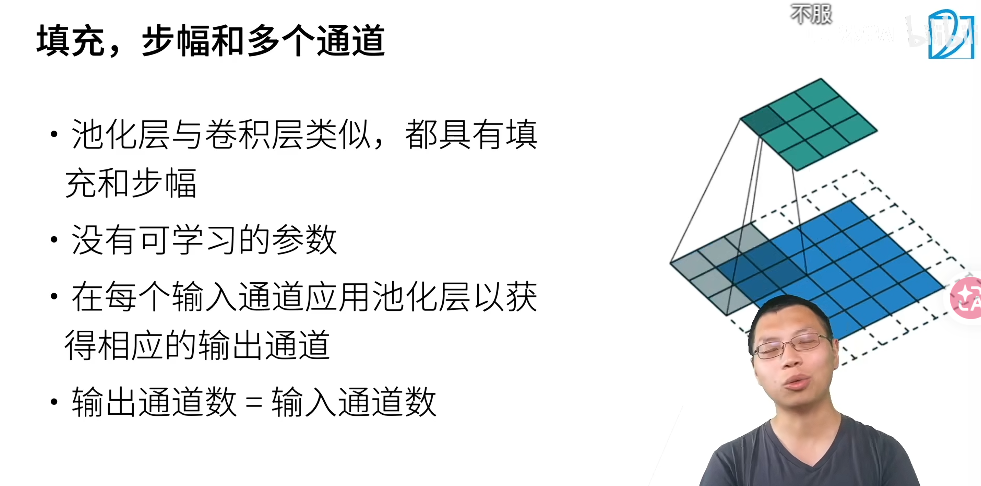

不会融合通道，输入通道数 = 输出通道数

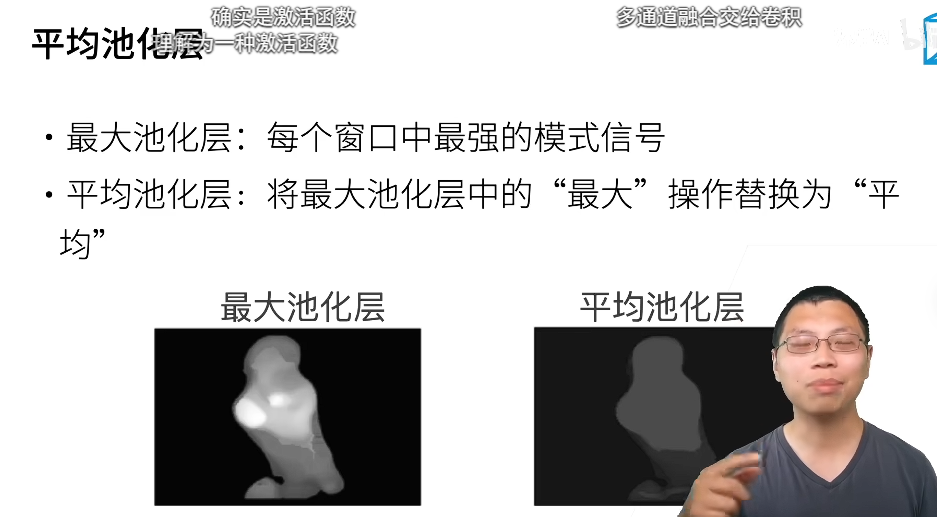

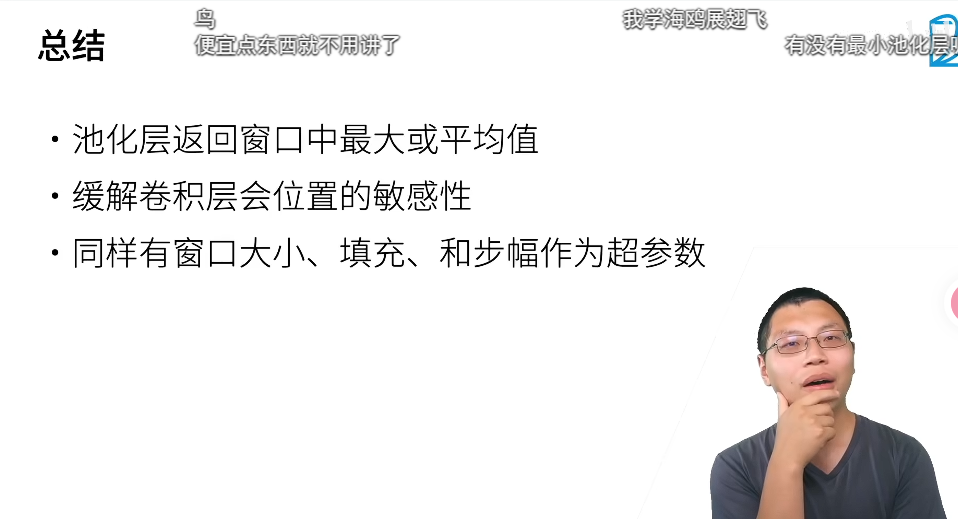

1. 卷积层：特征提取器（“找局部特征”）
   
卷积层的意义在于提取图像的局部特征。它通过一个个小窗口（卷积核）在图像上滑动，逐一检查每个小区域。

2. 池化层：降采样器（“浓缩精华”）
   
池化层的意义在于降低数据的空间尺寸（缩小长宽），同时保留最重要的信息。它通常紧跟在卷积层后面。

池化层可以缓解卷积层对位置的敏感性

## 代码

In [1]:
import torch
from torch import nn
from d2l import torch as d2l

In [ ]:
# 滑动窗口找最大/平均值
def pool2d(X, pool_size, mode='max'):
    p_h, p_w = pool_size
    Y = torch.zeros((X.shape[0] - p_h + 1, X.shape[1] - p_w + 1))
    for i in range(Y.shape[0]):
        for j in range(Y.shape[1]):
            if mode == 'max':
                Y[i, j] = X[i: i + p_h, j: j + p_w].max()
            elif mode == 'avg':
                Y[i, j] = X[i: i + p_h, j: j + p_w].mean()
    return Y

In [3]:
X = torch.tensor([[0.0, 1.0, 2.0], [3.0, 4.0, 5.0], [6.0, 7.0, 8.0]])
pool2d(X, (2, 2))

tensor([[4., 5.],
        [7., 8.]])

平均池化

In [4]:
pool2d(X, (2, 2), 'avg')

tensor([[2., 3.],
        [5., 6.]])

填充和步幅

In [5]:
X = torch.arange(16, dtype=torch.float32).reshape((1, 1, 4, 4))
X

tensor([[[[ 0.,  1.,  2.,  3.],
          [ 4.,  5.,  6.,  7.],
          [ 8.,  9., 10., 11.],
          [12., 13., 14., 15.]]]])

深度学习框架中步幅和池化窗口的大小相同

In [ ]:
pool2d = nn.MaxPool2d(3)  #窗口大小和步幅都为3
pool2d(X)

tensor([[[[10.]]]])

可以手动设定填充和步幅、窗口大小

In [7]:
pool2d = nn.MaxPool2d(3, padding=1, stride=2)
pool2d(X)

tensor([[[[ 5.,  7.],
          [13., 15.]]]])

In [8]:
pool2d = nn.MaxPool2d((2, 3), stride=(2, 3), padding=(0, 1))
pool2d(X)

tensor([[[[ 5.,  7.],
          [13., 15.]]]])

池化层在每个通道上单独运算

In [ ]:
X = torch.cat((X, X + 1), 1)  # axis = 1
X

tensor([[[[ 0.,  1.,  2.,  3.],
          [ 4.,  5.,  6.,  7.],
          [ 8.,  9., 10., 11.],
          [12., 13., 14., 15.]],

         [[ 1.,  2.,  3.,  4.],
          [ 5.,  6.,  7.,  8.],
          [ 9., 10., 11., 12.],
          [13., 14., 15., 16.]]]])

In [10]:
pool2d = nn.MaxPool2d(3, padding=1, stride=2)
pool2d(X)

tensor([[[[ 5.,  7.],
          [13., 15.]],

         [[ 6.,  8.],
          [14., 16.]]]])